\title{Assignment 1}
\author{Thomas Seeberg Christiansen}
\date{\today}

\maketitle

# Problem 1

## a) NLP

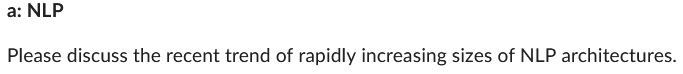

## b) Transfer Learning

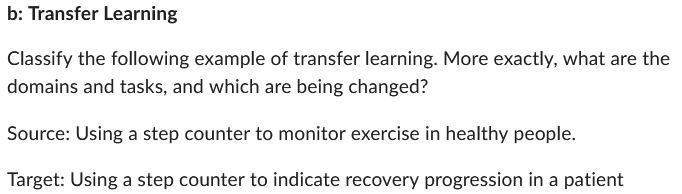

The domains and tasks can be defined as the following. The Source and Target domains are in this case a step counter as the "optimization parameter". The tasks are, however, different between the Source and the Target. The Source tasks is monitoring exercise in healthy people and the Target tasks is indicating recovery progression in a patient. 
$$
\begin{aligned}
    D_S&: \text{Step Counter} & T_S&: \text{Monitor exercise} \\
    D_T&: \text{Step Counter} & T_T&: \text{Indicate recovery progression} 
\end{aligned}
$$
In conclusion, we are dealing with inductive transfer learning, since we see $D_S=D_T$ and $T_S\neq T_T$.

## c) Attention

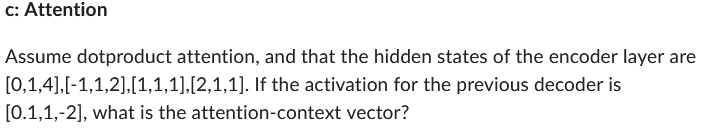

Dot product attention is defined as $a_{ij}=s_{i-1}^T h_j$, where $h$ are our, in this case, 4 hidden states and $s_{i-1}$ being our previous decoder activation. Hence:
$$
\begin{aligned}
    h_1 &= [0,1,4] \\
    h_2 &= [-1,1,2] \\
    h_3 &= [1,1,1] \\
    h_4 &= [2,1,1] \\
    s_{i-1} &= [0.1,1,-2]^T
\end{aligned}
$$
The attention-context vector is found by $c_i=\sum_j \alpha_{ij}h_j$, with the attention weight as $\alpha_{ij}=\frac{e^{a_{ij}}}{\sum_k e^{a_{ik}}}$. This can be calculated using the following Python code:

In [35]:
import numpy as np
s_p1 = np.array([0.1,1,-2]).T
h = np.array([[0,1,4],[-1,1,2],[1,1,1],[2,1,1]]).T
a_ij = np.dot(s_p1,h)
alpha_ij = np.exp(a_ij)/(np.sum(np.exp(a_ij)))
c_i = np.matmul(alpha_ij,h.T)
print(f'c_i = {c_i}')

c_i = [1.39731088 1.         1.05298479]


Thus, the resulting attention context vector is $c_i=[1.39,1.,1.05]$

## d) Transformers

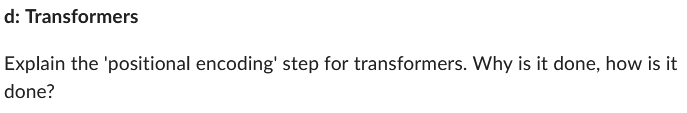

We lose all positional features from the input sequence when using transformers, due to the multi-head attention effecient way of parallelizing the network. This means if we pass a spoken langauge sentence through, the network wouldn't know the order of anything and the sentences would lose its meaning. The solution is encoding positional information onto each token with a unique position related signal. It adds a tensor with a specific pattern based on sine and cosine functions which captures the relative distance, or relation, to other inputs. This means the network can recognize the order of the words and the distance between them, effectively retaining sequence structures. 

## e) Bounding Box Detection

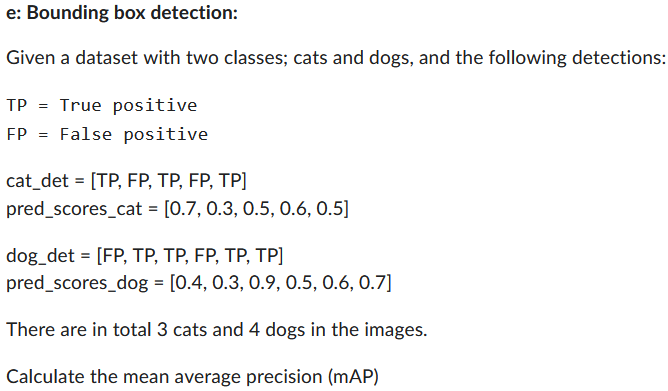

$$AP=\sum_n(R_{n+1}-R_nP)(R_{n+1})$$
$$mAP=(AP_{dog}+AP_{cat})/2$$

In [37]:
# Data for cats
cat_det = np.array([1, 0, 1, 0, 1])  # 1 for TP, 0 for FP
pred_scores_cat = np.array([0.7, 0.3, 0.5, 0.6, 0.5])
total_cats = 3  # total ground truth positives for cats

# Data for dogs
dog_det = np.array([0, 1, 1, 0, 1, 1])  # 1 for TP, 0 for FP
pred_scores_dog = np.array([0.4, 0.3, 0.9, 0.5, 0.6, 0.7])
total_dogs = 4  # total ground truth positives for dogs

# Function to calculate Average Precision (AP)
def calculate_ap(detections, scores, total_positives):
    # Sort detections by prediction scores in descending order
    sorted_indices = np.argsort(scores)[::-1]
    sorted_detections = detections[sorted_indices]
    
    # Calculate precision and recall at each threshold
    tp_cumsum = np.cumsum(sorted_detections)
    fp_cumsum = np.cumsum(1 - sorted_detections)
    
    precisions = tp_cumsum / (tp_cumsum + fp_cumsum)
    recalls = tp_cumsum / total_positives
    
    # AP is the area under the precision-recall curve
    ap = np.sum((recalls[1:] - recalls[:-1]) * precisions[1:])
    return ap

# Calculate AP for each class
ap_cat = calculate_ap(cat_det, pred_scores_cat, total_cats)
ap_dog = calculate_ap(dog_det, pred_scores_dog, total_dogs)

# Calculate mean Average Precision (mAP)
mAP = (ap_cat + ap_dog) / 2
print("AP for cats:", ap_cat)
print("AP for dogs:", ap_dog)
print("Mean Average Precision (mAP):", mAP)

AP for cats: 0.4722222222222222
AP for dogs: 0.6666666666666666
Mean Average Precision (mAP): 0.5694444444444444


## f) Semantic Segmentation - FCN 1

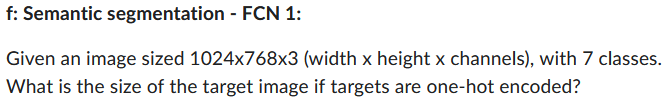

## g) Semantic Segmentation - FCN 2

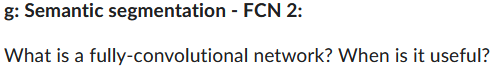

## h) Residual Networks

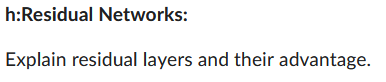

## i) Intersection-Over-Union

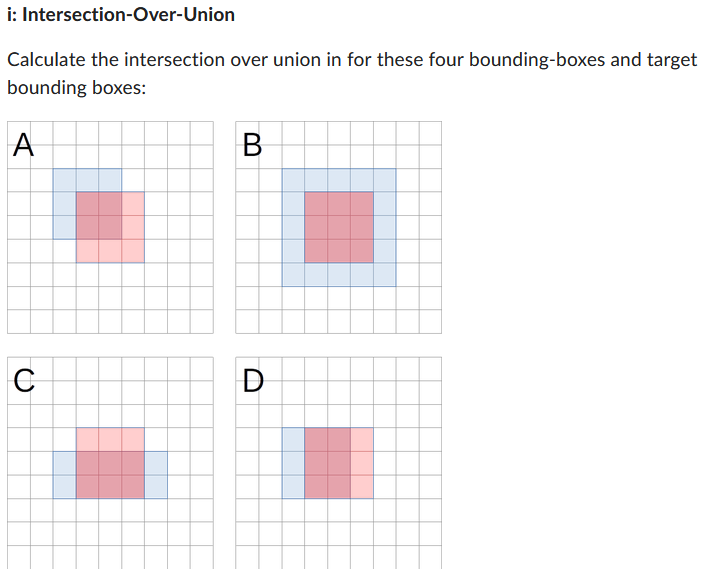

## j) Variational Autoencoders

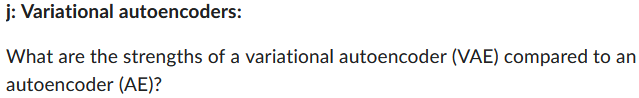

# Problem 2